In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import wasserstein_distance, spearmanr,  pearsonr
import matplotlib.pyplot as plt


from skimage.metrics import structural_similarity as ssim

from matplotlib.colors import CenteredNorm
from torchview import draw_graph
from torchmetrics.functional.regression import r2_score as torch_r2_score
from torchmetrics.functional.image import structural_similarity_index_measure

from astral import moon

from io import BytesIO

from openpyxl.drawing.image import Image
import json


In [ ]:
dry_run = False
todas = False
sp = "HKP"
# Initialize with your desired parameters
from dataset import DataBuilder
data_builder = DataBuilder(
    target_var="cpue_index",
    sp=sp, 
    todas=todas,
    window_size=12,
    batch_size=24
)

# Fetch the DataLoaders
train_loader, val_loader, test_loader = data_builder.get_loaders()
in_channels = data_builder.in_channels
out_hw = data_builder.out_hw

In [4]:
#-------- Custom Geospatial Loss Module --------
class GeospatialLoss(nn.Module):
    def __init__(self, ssim_weight=1.0, window_size=7, huber_delta=1.0):
        super().__init__()
        self.ssim_weight = ssim_weight
        self.window_size = window_size
        self.huber_delta = huber_delta

    def forward(self, pred, target, mask):
        """
        pred:   (B, 1, H, W)
        target: (B, H, W)
        mask:   (B, H, W)
        """
        # Ensure target and mask match prediction dimensions
        target = target.unsqueeze(1) 
        mask = mask.unsqueeze(1).float() # (B, 1, H, W)
        
        # 1. Huber Loss: Computed pixel-wise, then masked and averaged
        base_loss = F.huber_loss(pred, target, reduction='none', delta=self.huber_delta)
        masked_base_loss = (base_loss * mask).sum() / (mask.sum() + 1e-8)
        
        # 2. Fully Differentiable Masked SSIM
        ssim_loss = self._differentiable_ssim(pred, target, mask)
        
        return masked_base_loss + (self.ssim_weight * ssim_loss)

    def _differentiable_ssim(self, pred, target, mask):
        # Capture target spatial dimensions to prevent padding overshoots
        _, _, H, W = pred.shape
        
        # Apply mask
        valid = mask > 0
        pred_masked = torch.where(valid, pred, torch.zeros_like(pred))
        target_masked = torch.where(valid, target, torch.zeros_like(target))

        # Dynamically calculate the data range per image in the batch
        max_val = target_masked.amax(dim=(2, 3), keepdim=True)
        min_val = target_masked.amin(dim=(2, 3), keepdim=True)

        data_range = max_val - min_val + 1e-8
        
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2

        pad = self.window_size // 2

        # Calculate means using avg_pool2d
        # Note: stride=1 is required to ensure the output spatial dimensions match the input
        mu1 = F.avg_pool2d(pred_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W]
        mu2 = F.avg_pool2d(target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        # Calculate variances using avg_pool2d
        sigma1_sq = F.avg_pool2d(pred_masked * pred_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.avg_pool2d(target_masked * target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.avg_pool2d(pred_masked * target_masked, kernel_size=self.window_size, stride=1, padding=pad)[:, :, :H, :W] - mu1_mu2

        # SSIM map calculation
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Apply mask to SSIM map safely
        masked_ssim = (ssim_map * mask).sum() / (mask.sum() + 1e-8)
        
        # Minimize loss -> return 1 - SSIM
        return 1.0 - masked_ssim

In [ ]:
# -------------- Training Loop --------------
from modelos_DL import UNet3DReg

iters = 10
list_of_r2_train = []
list_of_r2_val = []
list_of_train_loss = []
list_of_val_loss = []

for i in range(iters):
    
    print(f"----------------------------------------------------Iteration {i+1}/{iters}-----------------------------------------------------------------------")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet3DReg(in_channels=in_channels, out_hw=out_hw, out_channels=1, base_ch=10).to(device)

    model_name = model.__class__.__name__
    if dry_run:
        print("No training")
        break

    criterion = GeospatialLoss(ssim_weight=1, huber_delta=4).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=30)

    best_test_r2 = -float("inf")
    best_test_ssim = -float("inf")
    best_combined_score = float("-inf")
    best_model_path = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"
    if todas: 
        best_model_path = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}_todas.pth"

    patience = 40
    epochs = 300
    counter = 0

    train_r2_history = []
    val_r2_history = []
    train_loss_history = []
    val_loss_history = []
    
    test_ssim_history = [] 

    # -------- Training loop --------
    for epoch in range(epochs):

        # -------- Training --------
        model.train()
        total_loss = 0.0
        train_r2s = []

        for x, y, m in train_loader:
        # for x, y, m in train_residual_loader:

            x = x.to(device)      # (B,T,C,H,W)
            y = y.to(device)      # (B,H,W)
            m = m.to(device)      # (B,H,W)

            optimizer.zero_grad()
            pred = model(x)       # (B,1,H,W)

            # ----- Loss -----
            loss = criterion(pred, y, m)
            # loss = MSE_SSIM_loss(pred, y, m, ssim_weight=1.0)
            # loss = huber_SSIM_loss(pred, y, m, ssim_weight=0.5, huber_delta=0.5)

            loss.backward()
            optimizer.step()

            total_loss += loss.detach()
            # ----- Metrics -----
            pred_np = pred.detach().cpu().squeeze(1).numpy()   # (B,H,W)
            y_np = y.detach().cpu().numpy()                    # (B,H,W)
            m_np = m.detach().cpu().numpy()                    # (B,H,W)
            
            # Flatten and filter by mask
            y_true = y_np.reshape(-1)
            y_pred = pred_np.reshape(-1)
            m_flat = m_np.reshape(-1)
            
            valid_idx = m_flat > 0.5 
            y_true_valid = y_true[valid_idx]
            y_pred_valid = y_pred[valid_idx]

            if len(y_true_valid) > 1:
                train_r2s.append(r2_score(y_true_valid, y_pred_valid))
        epoch_train_loss = (total_loss / len(train_loader)).cpu().item()
        train_loss_history.append(epoch_train_loss)
        train_r2 = np.mean(train_r2s) if len(train_r2s) > 0 else float("nan")
        # =====================================================
        # -------- Validation --------
        # =====================================================
        model.eval()

        # Lists to accumulate flat masked data for global regression metrics
        all_y_true_valid = []
        all_y_pred_valid = []
        
        # SSIM is an image-level metric, so we still accumulate it per-image
        test_ssims = []

        total_val_loss = 0.0
        with torch.no_grad():
            for x, y, m in val_loader:
            # for x, y, m in test_residual_loader:
                x = x.to(device)
                y = y.to(device)
                m = m.to(device)

                pred = model(x)
                loss = criterion(pred, y, m)
                total_val_loss += loss.detach().item()
                # ----- Convert to numpy -----
                pred_np = pred.detach().cpu().squeeze(1).numpy()
                y_np = y.detach().cpu().numpy()
                m_np = m.detach().cpu().numpy()

                # ----- 1. Accumulate Global Data for Regression Metrics -----
                y_true_flat = y_np.reshape(-1)
                y_pred_flat = pred_np.reshape(-1)
                m_flat = m_np.reshape(-1)
                
                valid_idx = m_flat > 0.5
                
                # Append only the valid pixels to our global lists
                all_y_true_valid.append(y_true_flat[valid_idx])
                all_y_pred_valid.append(y_pred_flat[valid_idx])

                # ----- 2. Masked SSIM Calculation (Per Image) -----
                y_np_spatial = y_np.reshape(pred_np.shape)
                m_np_spatial = m_np.reshape(pred_np.shape)
                
                data_range = 1.0 
                for i in range(len(pred_np)):
                    min_dim = min(y_np_spatial[i].shape)  
                    win_size = min(11, min_dim)
                    if win_size % 2 == 0:
                        win_size -= 1
                    if win_size < 3: 
                        win_size = 3
                    
                    _, ssim_img = ssim(
                        y_np_spatial[i], 
                        pred_np[i], 
                        data_range=data_range, 
                        win_size=win_size, 
                        gaussian_weights=True, 
                        full=True
                    )
                    
                    valid_mask = m_np_spatial[i] > 0.5
                    if valid_mask.sum() > 0:
                        masked_score = ssim_img[valid_mask].mean()
                        test_ssims.append(masked_score)
            epoch_val_loss = total_val_loss / len(test_loader)
            val_loss_history.append(epoch_val_loss)
        # =====================================================
        # ----- Final Global Metric Computation -----
        # =====================================================
        
        # Concatenate all batches into single 1D arrays
        if len(all_y_true_valid) > 0:
            global_y_true = np.concatenate(all_y_true_valid)
            global_y_pred = np.concatenate(all_y_pred_valid)
        else:
            global_y_true, global_y_pred = np.array([]), np.array([])

        # Compute global regression metrics
        if len(global_y_true) > 1:
            test_r2 = r2_score(global_y_true, global_y_pred)
            test_mae = mean_absolute_error(global_y_true, global_y_pred)
            test_bias = np.mean(global_y_pred - global_y_true)
            
            # Protect pearson from perfectly flat arrays
            if np.std(global_y_true) > 0 and np.std(global_y_pred) > 0:
                test_corr = pearsonr(global_y_true, global_y_pred)[0]
            else:
                test_corr = float("nan")
        else:
            test_r2 = float("nan")
            test_mae = float("nan")
            test_bias = float("nan")
            test_corr = float("nan")

        # Average the valid image-level SSIMs
        test_ssim = np.mean(test_ssims) if len(test_ssims) > 0 else float("nan")
        # =====================================================
        # -------- Early stopping --------
        # =====================================================
        improved = False
        scheduler.step(test_r2)
        if test_r2 > best_test_r2:
            best_test_r2 = test_r2
            improved = True
        if test_ssim > best_test_ssim:
            best_test_ssim = test_ssim
            improved = True
        
        combined_score = 0.8*test_r2 + 0.2*test_ssim
        if combined_score > best_combined_score:
            best_combined_score = combined_score
            improved = True
            torch.save(model.state_dict(), best_model_path)
            print("Saved")
                
        if improved:
            counter = 0
        else:
            counter += 1
            
        if counter >= patience:
            print("Early stopping")
            break

        # -------- Logging --------
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {total_loss/len(train_loader):.4f} | "
            f"Train R2: {train_r2:.3f} | "
            f"R2: {test_r2:.3f} | "
            f"Best R2: {best_test_r2:.3f} | "
            f"Best Score: {best_combined_score:.3f} | "
            f"SSIM: {test_ssim:.3f} | "
            f"BestSSIM: {best_test_ssim:.3f} | "
            f"Bias: {test_bias:.3f} | "
            f"Corr: {test_corr:.3f}"
        )

        train_r2_history.append(train_r2)
        val_r2_history.append(test_r2)

    list_of_r2_train.append(train_r2_history)
    list_of_r2_val.append(val_r2_history)
    list_of_train_loss.append(train_loss_history)
    list_of_val_loss.append(val_loss_history)




----------------------------------------------------Iteration 1/10-----------------------------------------------------------------------
Saved
Epoch 1/300 | Loss: 2.2869 | Train R2: -0.035 | R2: -0.032 | Best R2: -0.032 | Best Score: -0.026 | SSIM: -0.000 | BestSSIM: -0.000 | Bias: -0.296 | Corr: 0.236
Saved
Epoch 2/300 | Loss: 2.2346 | Train R2: -0.007 | R2: -0.025 | Best R2: -0.025 | Best Score: -0.020 | SSIM: 0.000 | BestSSIM: 0.000 | Bias: -0.269 | Corr: 0.334
Saved
Epoch 3/300 | Loss: 2.2200 | Train R2: -0.006 | R2: -0.018 | Best R2: -0.018 | Best Score: -0.014 | SSIM: 0.001 | BestSSIM: 0.001 | Bias: -0.242 | Corr: 0.388
Saved
Epoch 4/300 | Loss: 2.1056 | Train R2: 0.062 | R2: -0.007 | Best R2: -0.007 | Best Score: -0.005 | SSIM: 0.002 | BestSSIM: 0.002 | Bias: -0.218 | Corr: 0.442
Saved
Epoch 5/300 | Loss: 2.0269 | Train R2: 0.104 | R2: 0.050 | Best R2: 0.050 | Best Score: 0.043 | SSIM: 0.012 | BestSSIM: 0.012 | Bias: -0.136 | Corr: 0.501
Saved
Epoch 6/300 | Loss: 1.9610 | Train

In [6]:
if not dry_run:
    data = {
        "list_of_r2_train": list_of_r2_train,
        "list_of_r2_val": list_of_r2_val,
        "list_of_train_loss": list_of_train_loss,
        "list_of_val_loss": list_of_val_loss
    }
    
    filepath = f"./modelos/runs/Regression/tloop_{model_name}_{sp}.json"
    if todas:
        filepath = f"./modelos/runs/Regression/tloop_{model_name}_{sp}_todas.json"
    with open(filepath, "w") as file:
        json.dump(data, file, indent=2)

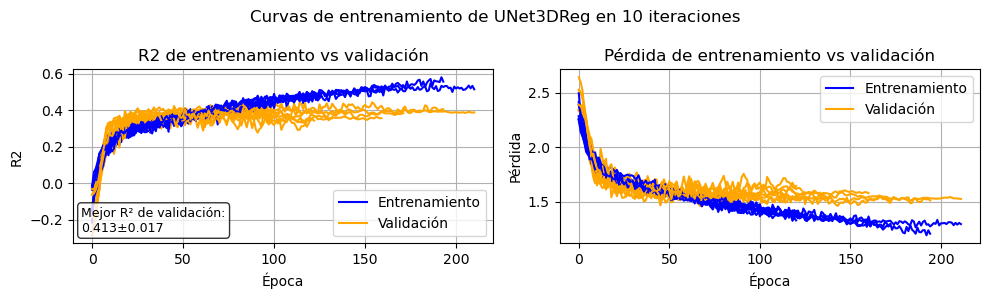

0

In [7]:

with open(filepath, "r") as file:
    data = json.load(file)
list_of_r2_train = data["list_of_r2_train"]
list_of_r2_val = data["list_of_r2_val"]
list_of_train_loss = data["list_of_train_loss"]
list_of_val_loss = data["list_of_val_loss"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle(f"Curvas de entrenamiento de {model_name} en {iters} iteraciones", fontsize=12)
for i in range(len(list_of_r2_train) - 1):
    axes[0].plot(list_of_r2_train[i], color="blue")
    axes[0].plot(list_of_r2_val[i], color="orange")
axes[0].plot(list_of_r2_train[-1], color="blue", label="Entrenamiento")
axes[0].plot(list_of_r2_val[-1], color="orange", label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("R2")
axes[0].set_title("R2 de entrenamiento vs validación")
axes[0].grid(True)
axes[0].legend()

for i in range(len(list_of_train_loss) - 1):
    axes[1].plot(list_of_train_loss[i], color="blue")
    axes[1].plot(list_of_val_loss[i], color="orange")
axes[1].plot(list_of_train_loss[-1], color="blue", label="Entrenamiento")
axes[1].plot(list_of_val_loss[-1], color="orange", label="Validación")



axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].set_title("Pérdida de entrenamiento vs validación")
axes[1].grid(True)
axes[1].legend()

best_val_r2 = np.array([np.max(r2_curve) for r2_curve in list_of_r2_val])
mean_best_val_r2 = best_val_r2.mean()
std_best_val_r2 = best_val_r2.std()
# Text annotation inside the plot
axes[0].text(
    0.02,
    0.05,
    f"Mejor R² de validación:\n{mean_best_val_r2:.3f}±{std_best_val_r2:.3f}",
    transform=axes[0].transAxes,
    fontsize=9,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)


In [8]:
def regression_metrics_dl(y_true, y_pred, mask_spatial):
    mask_bool = mask_spatial.astype(bool)


    # =====================================================
    # 1. FLATTEN FOR METRICS
    # =====================================================
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    if mask_bool.ndim == 2:
        mask_flat = np.broadcast_to(mask_bool, y_true.shape).flatten()
    else:
        mask_flat = mask_bool.flatten()

    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    
    # =====================================================
    # 4. MASKED SSIM
    # =====================================================
    data_range = 1.0 
    ssim_scores = []

    for i in range(y_true.shape[0]):
        _, ssim_map = ssim(
            y_true[i], y_pred[i],
            data_range=data_range, 
            win_size=11,           # Standard size
            gaussian_weights=True, # Weights center pixels more, like human vision
            full=True
        )
        current_mask = mask_bool if mask_bool.ndim == 2 else mask_bool[i]
        valid_ssim_pixels = ssim_map[current_mask]

        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))
    mean_ssim = np.mean(ssim_scores)



    # =====================================================
    # TIME SERIES COMPARISON (MASKED)
    # =====================================================
    y_true_time = []
    y_pred_time = []

    for i in range(y_true.shape[0]):
        current_mask = mask_bool if mask_bool.ndim == 2 else mask_bool[i]
        
        y_true_time.append(np.mean(y_true[i][current_mask]))
        y_pred_time.append(np.mean(y_pred[i][current_mask]))

    y_true_plot2 = np.array(y_true_time)
    y_pred_plot2 = np.array(y_pred_time)
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    print(f"R2: {r2:.4f}, Pearson: {pearson_corr:.4f}, Spearman: {spearman_corr:.4f}, Mean Masked SSIM: {mean_ssim:.4f}")
    list_of_metrics = [r2, pearson_corr, r2_plot2, mean_ssim, rmse, nrmse, mae, mbe, w_dist, spearman_corr]
    return list_of_metrics


In [9]:
columns = ["r2", "pearson_corr", "r2_plot","mean_ssim", "rmse", "nrmse", "mae", "mbe", "w_dist", "spearman_corr"]
metrics_df = pd.DataFrame(columns=columns)

for i in range(iters):
    print(f"--------------------------------Iteration {i+1}/{iters}------------------------------------------------------------------------------------------------------")
    file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"
    if todas:
        file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}_todas.pth"
    model.load_state_dict(torch.load(file, map_location=device))
    model.to(device)
    model.eval()
    all_preds = []
    all_targets = []
    all_masks = []  

    with torch.no_grad():
        for x, y, m in test_loader:
            x = x.to(device)
            
            # Output shape: (B, H, W)
            pred = model(x).squeeze(1) 

            # Keep them raw; do not multiply by m here
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.cpu().numpy())
            all_masks.append(m.cpu().numpy())

    # Concatenate along the batch dimension (N, H, W)
    all_preds = np.concatenate(all_preds, axis=0)     
    all_targets = np.concatenate(all_targets, axis=0) 
    all_masks = np.concatenate(all_masks, axis=0)

    mean_pred = all_preds.mean(axis=0)     # (H, W)
    mean_true = all_targets.mean(axis=0)   # (H, W)
    metrics = regression_metrics_dl(
        y_true=all_targets, 
        y_pred=all_preds, 
        mask_spatial=all_masks
    )
    metrics_df.loc[len(metrics_df)] = metrics




--------------------------------Iteration 1/10------------------------------------------------------------------------------------------------------
R2: 0.4766, Pearson: 0.7108, Spearman: 0.6463, Mean Masked SSIM: 0.2058
--------------------------------Iteration 2/10------------------------------------------------------------------------------------------------------
R2: 0.4593, Pearson: 0.6779, Spearman: 0.6470, Mean Masked SSIM: 0.2463
--------------------------------Iteration 3/10------------------------------------------------------------------------------------------------------
R2: 0.3957, Pearson: 0.6306, Spearman: 0.5749, Mean Masked SSIM: 0.2266
--------------------------------Iteration 4/10------------------------------------------------------------------------------------------------------
R2: 0.4779, Pearson: 0.6913, Spearman: 0.6251, Mean Masked SSIM: 0.2254
--------------------------------Iteration 5/10----------------------------------------------------------------------

In [10]:
display(metrics_df)

metrics_summary_df = pd.DataFrame(
    {col: [f"{metrics_df[col].mean():.3f}±{metrics_df[col].std():.3f}"]for col in metrics_df.columns})

display(metrics_summary_df)

,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr
0,0.476565,0.710807,0.745459,0.205823,1.282347,0.111516,0.712596,-0.114419,0.516628,0.646321
1,0.459270,0.677888,0.735833,0.246311,1.303361,0.113343,0.732659,0.011799,0.415408,0.646959
2,0.395672,0.630649,0.718036,0.226585,1.377878,0.119824,0.731276,-0.080055,0.440256,0.574860
3,0.477919,0.691347,0.799823,0.225369,1.280688,0.111372,0.732332,0.011273,0.408785,0.625064
4,0.455251,0.683164,0.769625,0.182313,1.308195,0.113764,0.726306,-0.159231,0.456637,0.650583
5,0.443987,0.666701,0.705789,0.205709,1.321651,0.114934,0.743687,-0.020186,0.416573,0.640259
6,0.530108,0.735517,0.838493,0.223778,1.214992,0.105659,0.696551,-0.076166,0.432629,0.635818
7,0.455797,0.676537,0.790174,0.213603,1.307539,0.113707,0.747678,-0.054663,0.458413,0.634076
8,0.452785,0.683528,0.792221,0.174109,1.311153,0.114021,0.751265,-0.074899,0.505624,0.651164
9,0.456512,0.684909,0.746135,0.188793,1.306680,0.113632,0.738003,-0.055177,0.498637,0.648852


,r2,pearson_corr,r2_plot,mean_ssim,rmse,nrmse,mae,mbe,w_dist,spearman_corr
0,0.460±0.033,0.684±0.027,0.764±0.041,0.209±0.023,1.301±0.040,0.113±0.004,0.731±0.017,-0.061±0.053,0.455±0.040,0.635±0.023


In [ ]:
def evaluate_with_zeroed_channel(model, loader, channel_to_zero, device):
    model.eval()
    
    total_loss = 0.0
    total_r2 = 0.0
    total_ssim = 0.0
    total_samples = 0

    with torch.no_grad():
        for x, y, m in loader:
            x = x.clone().to(device)
            y = y.to(device)
            m = m.to(device)
            
            batch_size = x.size(0)

            if isinstance(channel_to_zero, int):
                x[:, :, channel_to_zero, :, :] = 0
            if channel_to_zero ==  "all":
                x[:, :, :, :, :] = 0

            pred = model(x)
            loss = criterion(pred, y, m)
            pred_matched = pred.view_as(y)
            
            # --- GPU R2 Score (Mask-Aware) ---
            m_bool = m > 0.5
            y_true_flat = y[m_bool]
            y_pred_flat = pred_matched[m_bool]

            if y_true_flat.numel() > 1 and torch.var(y_true_flat) > 0:
                r2 = torch_r2_score(y_pred_flat, y_true_flat)
            else:
                r2 = torch.tensor(0.0, device=device)

            H, W = y.shape[-2], y.shape[-1]
            y_slices = y.reshape(-1, 1, H, W)
            pred_slices = pred.reshape(-1, 1, H, W)
            
            # Dynamic data range calculation on GPU
            data_range = torch.clamp(y_slices.max() - y_slices.min(), min=1e-5)
            
            ssim_val = structural_similarity_index_measure(
                pred_slices, y_slices, data_range=data_range
            )

            # Weight metrics by batch size for an exact dataset-wide average
            total_loss += loss.item() * batch_size
            total_r2 += r2.item() * batch_size
            total_ssim += ssim_val.item() * batch_size
            total_samples += batch_size

    return (
        total_loss / total_samples, 
        total_r2 / total_samples, 
        total_ssim / total_samples
    )


all_importances = []

for i in range(iters):
    #compute baseline
    file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}.pth"
    if todas:
        file = f"./modelos/runs/Regression/{model_name}_{sp}_{i+1}_todas.pth"
    model.load_state_dict(torch.load(
        file,
        map_location=device
    ))
    model.to(device)

    baseline_loss, baseline_r2, baseline_ssim = evaluate_with_zeroed_channel(
        model, test_loader, channel_to_zero=None, device=device
    )

    loss_importances = []
    r2_importances = []
    ssim_importances = []

    features_names = data_builder.vars_names

    #compute importance for each channel
    for c in range(in_channels):
        loss, r2, ssim_val = evaluate_with_zeroed_channel(
            model, test_loader, channel_to_zero=c, device=device
        )

        loss_importances.append(loss - baseline_loss)
        r2_importances.append(baseline_r2 - r2)
        ssim_importances.append(baseline_ssim - ssim_val)

    df_importance = pd.DataFrame({
        "variable": features_names,
        "r2_importance": r2_importances,
        "ssim_importance": ssim_importances,
        "loss_importance": loss_importances,
    })

    df_importance["r2_drop_%"] = (
        df_importance["r2_importance"] / baseline_r2 * 100
    )

    all_importances.append(df_importance)

# Concatenate all model importances
all_df = pd.concat(all_importances, ignore_index=True)

# Compute mean and std for each variable
mean_df = all_df.groupby("variable").mean(numeric_only=True)
std_df = all_df.groupby("variable").std(numeric_only=True)

# Build "mean ± std" table
summary_df = pd.DataFrame(index=mean_df.index)

for col in mean_df.columns:
    summary_df[col] = [
        f"{m:.4f} ± {s:.4f}"
        for m, s in zip(mean_df[col], std_df[col])
    ]

# Sort using the numeric mean r2_importance
summary_df = summary_df.loc[
    mean_df["r2_importance"].sort_values(ascending=False).index
].reset_index()

display(summary_df)

,variable,r2_importance,ssim_importance,loss_importance,r2_drop_%
0,MSEN,0.1282 ± 0.0561,0.0413 ± 0.0475,0.2387 ± 0.1160,27.8180 ± 12.2491
1,VGO,0.1024 ± 0.0544,0.0084 ± 0.0175,0.1976 ± 0.1014,22.0147 ± 10.9738
2,TO,0.1010 ± 0.1495,0.0564 ± 0.0319,0.2047 ± 0.2939,20.6779 ± 29.1840
3,MCOS,0.0698 ± 0.1275,0.0716 ± 0.0838,0.1435 ± 0.2648,16.2821 ± 29.5147
4,UGO,0.0246 ± 0.0177,-0.0015 ± 0.0123,0.0501 ± 0.0351,5.2377 ± 3.7982
5,MLOTST,0.0161 ± 0.0371,0.0286 ± 0.0255,0.0511 ± 0.0887,3.8142 ± 7.9278


In [12]:
# save everyhtng to a excel workbook
sheet_name = f"{model_name}_{sp}"
if todas: 
    sheet_name = f"{model_name}_{sp}_todas"
with pd.ExcelWriter("./modelos/resultados/Regre/DL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    metrics_summary_df.to_excel(writer, sheet_name=sheet_name, startrow=1, index=False)
with pd.ExcelWriter("./modelos/resultados/Regre/DL_reg.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name, startrow=len(metrics_summary_df) + 3, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")